C:\Users\granb\AppData\Local\Temp\ipykernel_17728\242554017.py:50: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  yoy = df[["Headline", "Core", "Food", "Energy"]].pct_change(12) * 100


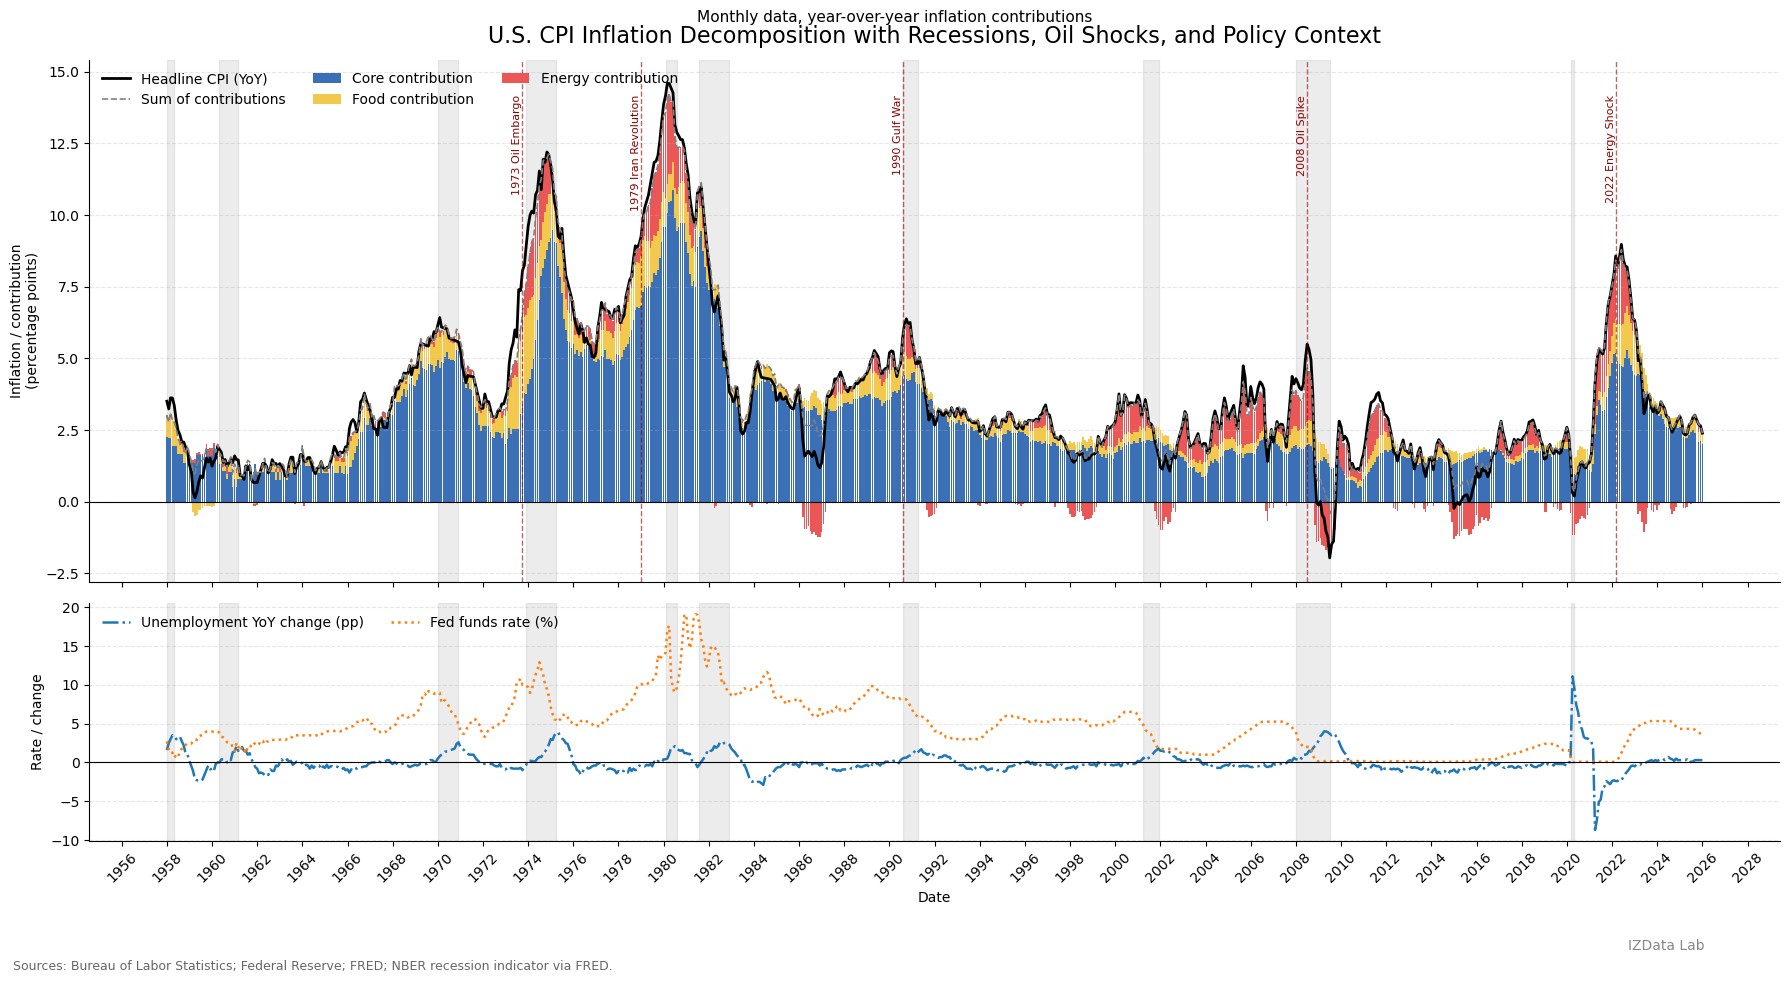

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# =========================
# 1. Load CSV files
# =========================
headline = pd.read_csv("CPIAUCSL.csv")
core = pd.read_csv("CPILFESL.csv")
food = pd.read_csv("CPIUFDSL.csv")
energy = pd.read_csv("CPIENGSL.csv")

# Additional macro series
unrate = pd.read_csv("UNRATE.csv")
fedfunds = pd.read_csv("FEDFUNDS.csv")
recession = pd.read_csv("USREC.csv")   # NBER recession indicator

# =========================
# 2. Convert dates
# =========================
for df_ in [headline, core, food, energy, unrate, fedfunds, recession]:
    df_["observation_date"] = pd.to_datetime(df_["observation_date"])

# =========================
# 3. Rename columns
# =========================
headline = headline.rename(columns={"observation_date": "Date", "CPIAUCSL": "Headline"})
core = core.rename(columns={"observation_date": "Date", "CPILFESL": "Core"})
food = food.rename(columns={"observation_date": "Date", "CPIUFDSL": "Food"})
energy = energy.rename(columns={"observation_date": "Date", "CPIENGSL": "Energy"})
unrate = unrate.rename(columns={"observation_date": "Date", "UNRATE": "Unemployment"})
fedfunds = fedfunds.rename(columns={"observation_date": "Date", "FEDFUNDS": "FedFunds"})
recession = recession.rename(columns={"observation_date": "Date", "USREC": "Recession"})

# =========================
# 4. Merge all series
# =========================
df = headline.merge(core, on="Date", how="inner")
df = df.merge(food, on="Date", how="inner")
df = df.merge(energy, on="Date", how="inner")
df = df.merge(unrate, on="Date", how="inner")
df = df.merge(fedfunds, on="Date", how="inner")
df = df.merge(recession, on="Date", how="left")
df = df.sort_values("Date").set_index("Date")

# =========================
# 5. Compute transformations
# =========================
# CPI YoY inflation
yoy = df[["Headline", "Core", "Food", "Energy"]].pct_change(12) * 100

# Unemployment YoY change in percentage points
unrate_yoy = df["Unemployment"] - df["Unemployment"].shift(12)

# Fed funds stays as level
fedfunds_level = df["FedFunds"]

plot_df = yoy.copy()
plot_df["Unemployment_YoY"] = unrate_yoy
plot_df["FedFunds"] = fedfunds_level
plot_df["Recession"] = df["Recession"]
plot_df = plot_df.dropna()

# =========================
# 6. BLS weights
# =========================
weights = {
    "Food": 13.698 / 100,
    "Energy": 6.383 / 100,
    "Core": 79.919 / 100,
}

# =========================
# 7. Weighted contributions
# =========================
contrib = pd.DataFrame(index=plot_df.index)
contrib["Core"] = plot_df["Core"] * weights["Core"]
contrib["Food"] = plot_df["Food"] * weights["Food"]
contrib["Energy"] = plot_df["Energy"] * weights["Energy"]
contrib["Headline"] = plot_df["Headline"]
contrib["Sum"] = contrib["Core"] + contrib["Food"] + contrib["Energy"]
contrib["Unemployment_YoY"] = plot_df["Unemployment_YoY"]
contrib["FedFunds"] = plot_df["FedFunds"]
contrib["Recession"] = plot_df["Recession"]

# =========================
# 8. Split positive/negative bars
# =========================
core_pos = contrib["Core"].clip(lower=0)
food_pos = contrib["Food"].clip(lower=0)
energy_pos = contrib["Energy"].clip(lower=0)

core_neg = contrib["Core"].clip(upper=0)
food_neg = contrib["Food"].clip(upper=0)
energy_neg = contrib["Energy"].clip(upper=0)

# =========================
# 9. Create two-panel figure
# =========================
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(18, 10),
    sharex=True,
    gridspec_kw={"height_ratios": [2.2, 1]}
)

bar_width = 25

# -------------------------
# Recession shading
# -------------------------
recession_start = None
for date, rec in contrib["Recession"].items():
    if rec == 1 and recession_start is None:
        recession_start = date
    elif rec == 0 and recession_start is not None:
        ax1.axvspan(recession_start, date, color="gray", alpha=0.15, zorder=0)
        ax2.axvspan(recession_start, date, color="gray", alpha=0.15, zorder=0)
        recession_start = None

# Handle recession continuing to the last observation
if recession_start is not None:
    ax1.axvspan(recession_start, contrib.index[-1], color="gray", alpha=0.15, zorder=0)
    ax2.axvspan(recession_start, contrib.index[-1], color="gray", alpha=0.15, zorder=0)

# -------------------------
# Top panel: CPI decomposition
# -------------------------
ax1.bar(contrib.index, core_pos, width=bar_width, color="#3B6FB6", label="Core contribution")
ax1.bar(contrib.index, food_pos, width=bar_width, bottom=core_pos, color="#F2C94C", label="Food contribution")
ax1.bar(contrib.index, energy_pos, width=bar_width, bottom=core_pos + food_pos, color="#EB5757", label="Energy contribution")

ax1.bar(contrib.index, core_neg, width=bar_width, color="#3B6FB6")
ax1.bar(contrib.index, food_neg, width=bar_width, bottom=core_neg, color="#F2C94C")
ax1.bar(contrib.index, energy_neg, width=bar_width, bottom=core_neg + food_neg, color="#EB5757")

ax1.plot(contrib.index, contrib["Headline"], color="black", linewidth=2.0, label="Headline CPI (YoY)")
ax1.plot(contrib.index, contrib["Sum"], color="gray", linestyle="--", linewidth=1.2, label="Sum of contributions")

# -------------------------
# Oil shock annotations
# -------------------------
oil_shocks = {
    "1973 Oil Embargo": "1973-10-01",
    "1979 Iran Revolution": "1979-01-01",
    "1990 Gulf War": "1990-08-01",
    "2008 Oil Spike": "2008-07-01",
    "2022 Energy Shock": "2022-03-01"
}

y_top = ax1.get_ylim()[1]

for label, date_str in oil_shocks.items():
    shock_date = pd.to_datetime(date_str)
    if contrib.index.min() <= shock_date <= contrib.index.max():
        ax1.axvline(shock_date, color="darkred", linestyle="--", linewidth=1.0, alpha=0.6)
        ax1.text(
            shock_date,
            y_top * 0.92,
            label,
            rotation=90,
            fontsize=8,
            color="darkred",
            ha="right",
            va="top"
        )

ax1.set_title("U.S. CPI Inflation Decomposition with Recessions, Oil Shocks, and Policy Context", fontsize=16, pad=12)
fig.suptitle("Monthly data, year-over-year inflation contributions", fontsize=11, y=0.97)
ax1.set_ylabel("Inflation / contribution\n(percentage points)")
ax1.axhline(0, color="black", linewidth=0.8)
ax1.grid(axis="y", linestyle="--", alpha=0.3)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.legend(frameon=False, ncol=3, loc="upper left")

# -------------------------
# Bottom panel: unemployment and fed funds
# -------------------------
ax2.plot(
    contrib.index,
    contrib["Unemployment_YoY"],
    linewidth=1.8,
    linestyle="-.",
    label="Unemployment YoY change (pp)"
)
ax2.plot(
    contrib.index,
    contrib["FedFunds"],
    linewidth=1.8,
    linestyle=":",
    label="Fed funds rate (%)"
)

ax2.axhline(0, color="black", linewidth=0.8)
ax2.set_ylabel("Rate / change")
ax2.set_xlabel("Date")
ax2.grid(axis="y", linestyle="--", alpha=0.3)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.legend(frameon=False, ncol=2, loc="upper left")

# =========================
# 10. Shared x-axis formatting
# =========================
ax2.xaxis.set_major_locator(mdates.YearLocator(2))
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.xticks(rotation=45)

# =========================
# Sources and watermark
# =========================
fig.text(
    0.01, 0.01,
    "Sources: Bureau of Labor Statistics; Federal Reserve; FRED; NBER recession indicator via FRED.",
    fontsize=9,
    color="#666666",
    ha="left"
)

fig.text(
    0.95, 0.03,
    "IZData Lab",
    fontsize=10,
    color="#888888",
    ha="right"
)

plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.savefig("US_CPI_with_UnRate_Fed_Fund_Recession_OilShock.png", dpi=300, bbox_inches="tight")
plt.show()